#### How to handle Categroical missing values.
##### Frequent Category Imputation

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib as plt 

%matplotlib inline

In [2]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\dataset_2.csv")
df.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


In [6]:
df.columns

Index(['Area_SqFt', 'Rooms', 'Build_Year', 'Location', 'Street_Type',
       'Furnishing', 'Property_Type', 'Has_Pool', 'Price'],
      dtype='object')

In [3]:
df.isnull().sum()

Area_SqFt        33
Rooms            33
Build_Year        0
Location          0
Street_Type       0
Furnishing       33
Property_Type     0
Has_Pool          0
Price             0
dtype: int64

In [9]:
df.isnull().mean().sort_values(ascending=True)

Build_Year       0.000000
Location         0.000000
Street_Type      0.000000
Property_Type    0.000000
Has_Pool         0.000000
Price            0.000000
Area_SqFt        0.029359
Rooms            0.029359
Furnishing       0.029359
dtype: float64

In [10]:
df.shape

(1124, 9)

<Axes: xlabel='Area_SqFt'>

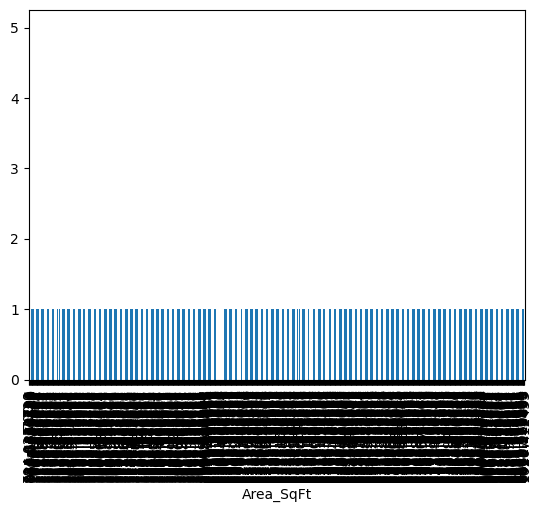

In [12]:
# Compute the frequency with every feature
df.groupby(['Area_SqFt'])['Rooms'].count().plot.bar()

###### Advantages:
1. Easy to implement.
2. Faster way to implement.
###### Disadvanatges:
1. Since we are using more frequent labels, it may use them in an over represented way , if there are many nans.
2. It distorts the relationship of the most frequent label.

In [13]:
# I didnt find the same data set but for the reffernce the code is this:
def impute_nan(df,variable):
    most_frequent_category=df[variable].mode()[0]
    df[variable].fillna(most_frequent_category,inplace=True)

In [ ]:
for feature in ['BsmtQual','FireplaceQu','GarageType']:
    impute_nan(df,feature)

In [ ]:
df.isnull().mean()

##### Using other dataset finally !

In [4]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\train.csv",usecols=['Sex'])
df.head()

,Sex
0,male
1,female
2,female
3,female
4,male


In [ ]:
## One hot encoding is already covered in previous notebook feature -1 or eda-4

#### Ordinal Number Encoding
 we can rank those categories

In [5]:
import datetime

In [6]:
today_date=datetime.datetime.today()

In [7]:
today_date

datetime.datetime(2026, 6, 21, 9, 48, 22, 323583)

In [11]:
today_date-datetime.timedelta(2)

datetime.datetime(2026, 6, 19, 9, 48, 22, 323583)

In [14]:
#### List Comprehension
days=[today_date-datetime.timedelta(x) for x in range(0,15)]

In [15]:
data=pd.DataFrame(days)
data.columns=["Days"]

In [16]:
data.head()

,Days
0,2026-06-21 09:48:22.323583
1,2026-06-20 09:48:22.323583
2,2026-06-19 09:48:22.323583
3,2026-06-18 09:48:22.323583
4,2026-06-17 09:48:22.323583


In [23]:
data['weekday']=data['Days'].dt.day_name()
data.head()

,Days,weekday
0,2026-06-21 09:48:22.323583,Sunday
1,2026-06-20 09:48:22.323583,Saturday
2,2026-06-19 09:48:22.323583,Friday
3,2026-06-18 09:48:22.323583,Thursday
4,2026-06-17 09:48:22.323583,Wednesday


In [24]:
dictionary={'Monday':1,'Tuesday':2,'Wednesday':3,'Thursday':4,'Friday':5,'Saturday':6,'Sunday':7}

In [25]:
dictionary

{'Monday': 1,
 'Tuesday': 2,
 'Wednesday': 3,
 'Thursday': 4,
 'Friday': 5,
 'Saturday': 6,
 'Sunday': 7}

In [27]:
data['weekday_ordinal']=data['weekday'].map(dictionary)

In [28]:
data

,Days,weekday,weekday_ordinal
0,2026-06-21 09:48:22.323583,Sunday,7
1,2026-06-20 09:48:22.323583,Saturday,6
2,2026-06-19 09:48:22.323583,Friday,5
3,2026-06-18 09:48:22.323583,Thursday,4
4,2026-06-17 09:48:22.323583,Wednesday,3
5,2026-06-16 09:48:22.323583,Tuesday,2
6,2026-06-15 09:48:22.323583,Monday,1
7,2026-06-14 09:48:22.323583,Sunday,7
8,2026-06-13 09:48:22.323583,Saturday,6
9,2026-06-12 09:48:22.323583,Friday,5


#### Count or frequency encoding

In [29]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Target Guided ordinal encoding
1. Ordering the labels according to the target
2. Replace the labels by the joint probability of being 1 or 0

In [2]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\train.csv",usecols=['Cabin','Survived'])
df.head()

,Survived,Cabin
0,0,NaN
1,1,C85
2,1,NaN
3,1,C123
4,0,NaN


In [3]:
df.isnull().sum()

Survived      0
Cabin       687
dtype: int64

In [5]:
df['Cabin'].fillna('Missing',inplace=True)
df.head()

,Survived,Cabin
0,0,Missing
1,1,C85
2,1,Missing
3,1,C123
4,0,Missing


In [7]:
df['Cabin']=df['Cabin'].astype(str).str[0]
df.head()

,Survived,Cabin
0,0,M
1,1,C
2,1,M
3,1,C
4,0,M


In [9]:
df.Cabin.unique()

array(['M', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [8]:
df.groupby(['Cabin'])['Survived'].mean()

Cabin
A    0.466667
B    0.744681
C    0.593220
D    0.757576
E    0.750000
F    0.615385
G    0.500000
M    0.299854
T    0.000000
Name: Survived, dtype: float64

In [12]:
df.groupby(['Cabin'])['Survived'].mean().sort_values().index

Index(['T', 'M', 'A', 'G', 'C', 'F', 'B', 'E', 'D'], dtype='object', name='Cabin')

In [13]:
ordinal_labels=df.groupby(['Cabin'])['Survived'].mean().sort_values().index
ordinal_labels

Index(['T', 'M', 'A', 'G', 'C', 'F', 'B', 'E', 'D'], dtype='object', name='Cabin')

In [14]:
enumerate(ordinal_labels,0)

In [15]:
ordinal_labels2={k:i for i,k in enumerate(ordinal_labels,0)}
ordinal_labels2

{'T': 0, 'M': 1, 'A': 2, 'G': 3, 'C': 4, 'F': 5, 'B': 6, 'E': 7, 'D': 8}

In [17]:
df['Cabin_ordinal_labels']=df['Cabin'].map(ordinal_labels2)
df.head()

,Survived,Cabin,Cabin_ordinal_labels
0,0,M,1
1,1,C,4
2,1,M,1
3,1,C,4
4,0,M,1


#### Mean Encoding

In [20]:
mean_ordinal=df.groupby(['Cabin'])['Survived'].mean().to_dict()

In [21]:
mean_ordinal

{'A': 0.4666666666666667,
 'B': 0.7446808510638298,
 'C': 0.5932203389830508,
 'D': 0.7575757575757576,
 'E': 0.75,
 'F': 0.6153846153846154,
 'G': 0.5,
 'M': 0.29985443959243085,
 'T': 0.0}

In [24]:
df['mean_ordinal_encode']=df['Cabin'].map(mean_ordinal)
df.head()

,Survived,Cabin,Cabin_ordinal_labels,mean_ordinal_encode
0,0,M,1,0.299854
1,1,C,4,0.593220
2,1,M,1,0.299854
3,1,C,4,0.593220
4,0,M,1,0.299854


##### Advantages--
1. Easy to implement.
2. it captures imformation within the label, therefore rendering more predectible features.
3. it creates a monotonic relationship between the variable and the target.
##### Disadvantages--
1. It prones to overfitting.

#### Probability Ratio Encoding

In [25]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\train.csv",usecols=['Cabin','Survived'])
df.head()

,Survived,Cabin
0,0,NaN
1,1,C85
2,1,NaN
3,1,C123
4,0,NaN


In [26]:
df['Cabin'].fillna('Missing',inplace=True)
df.head()

C:\Users\Asus\AppData\Local\Temp\ipykernel_21960\1199887496.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cabin'].fillna('Missing',inplace=True)


,Survived,Cabin
0,0,Missing
1,1,C85
2,1,Missing
3,1,C123
4,0,Missing


In [27]:
df['Cabin']=df['Cabin'].astype(str).str[0]
df.head()

,Survived,Cabin
0,0,M
1,1,C
2,1,M
3,1,C
4,0,M


In [28]:
df.Cabin.unique()

array(['M', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [32]:
prob_df=df.groupby(['Cabin'])['Survived'].mean()

In [34]:
prob_df= pd.DataFrame(prob_df)
prob_df

,Survived
Cabin,
A,0.466667
B,0.744681
C,0.593220
D,0.757576
E,0.750000
F,0.615385
G,0.500000
M,0.299854
T,0.000000


In [35]:
prob_df['Died']=1-prob_df['Survived']

In [36]:
prob_df.head()

,Survived,Died
Cabin,,
A,0.466667,0.533333
B,0.744681,0.255319
C,0.593220,0.406780
D,0.757576,0.242424
E,0.750000,0.250000


In [37]:
prob_df['Prob_ratio']=prob_df['Survived']/prob_df['Died']
prob_df.head()

,Survived,Died,Prob_ratio
Cabin,,,
A,0.466667,0.533333,0.875000
B,0.744681,0.255319,2.916667
C,0.593220,0.406780,1.458333
D,0.757576,0.242424,3.125000
E,0.750000,0.250000,3.000000


In [39]:
prob_encode=prob_df['Prob_ratio'].to_dict()

In [40]:
df['Cabin_encoded']=df['Cabin'].map(prob_encode)

In [41]:
df.head()

,Survived,Cabin,Cabin_encoded
0,0,M,0.428274
1,1,C,1.458333
2,1,M,0.428274
3,1,C,1.458333
4,0,M,0.428274


finally replace the categorical values with the encoded values!!